In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from nltk.corpus import stopwords 
import string 
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from feature_engine.selection import SmartCorrelatedSelection
from utils import display_model_dashboard, yeojohnson_transform_analysis, text_cleaner_spacy, evaluate_model, message_cleaning

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
df = pd.read_parquet('../data/yelp_data_prepared.parquet')

In [3]:
df.columns

Index(['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id',
       'cool', 'useful', 'funny', 'length', 'year', 'month', 'dayofweek',
       'day', 'is_weekend', 'user_count', 'business_count', 'word_count',
       'num_sentences', 'digit_count', 'num_exclam', 'num_questions',
       'score_afinn', 'score_vader', 'score_bing', 'nrc_pos', 'nrc_neg',
       'score_afinn_norm', 'score_bing_norm', 'nrc_pos_norm', 'nrc_neg_norm',
       'vader_deviation', 'polarity', 'subjectivity'],
      dtype='object')

In [4]:
df[df['length'] == 10]

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,...,score_bing,nrc_pos,nrc_neg,score_afinn_norm,score_bing_norm,nrc_pos_norm,nrc_neg_norm,vader_deviation,polarity,subjectivity
2892,AIaEFC65T7BKVl03INm1eg,2010-12-20,747-H8tvuxXOEMMviYBXiA,1,Great Job!,review,wtn-JNypbM7IupJm9t40Hw,0,0,0,...,1,0,0,1.5,0.5,0.0,0.0,0.000000,1.0,0.75
3854,Zw4CvOwXJj1QA85SvB99Hw,2011-01-17,lQLprkBt4W4XbgCHGe3HqQ,1,Awesome!!!,review,T7QG8ge2ukcfvEosSkg8yA,0,0,0,...,1,0,0,4.0,1.0,0.0,0.0,0.000000,1.0,1.00
4968,iV7D7fHKb-bF9fCL_bEMtA,2012-11-25,lfP-h9GlmgqqAlqcPgvXhQ,1,Excellent.,review,e-89w7FUWyUKgAELA75E3w,0,0,0,...,1,0,0,3.0,1.0,0.0,0.0,0.375733,1.0,1.00
5539,oWq_NiPJq20svbRCJ1hLGQ,2012-01-29,bb_bsu_zjTSgOZzbS5gbVw,1,Good works,review,nzhUfCzDUW8VFLc40nAtsA,0,0,0,...,2,0,0,1.5,1.0,0.0,0.0,0.000000,0.7,0.60


## Count Vectorizer

In [5]:
# Using only the review text column as predictors
X = df['text']
y = df['stars']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=0, 
    stratify=y    # Preserving the original class proportions
)

X_train.shape, X_test.shape

((3268,), (818,))

In [6]:
# Initialize the vectorizer
count_vectorizer = CountVectorizer( 
    tokenizer=message_cleaning,    # Custom function for text preparation.
    ngram_range=(1,2),             # Unigrams (1 word) and bigrams (word pairs).
    min_df=5                       # Ignore words that appear in fewer than 5 messages.
)

X_train_countvectorizer = count_vectorizer.fit_transform(X_train)
X_test_countvectorizer = count_vectorizer.transform(X_test)

**message_cleaning(message**) - a text preprocessing function that:
- removes punctuation (.,!?, etc.)
- removes stop words using the list from `nltk.corpus.stopwords`.

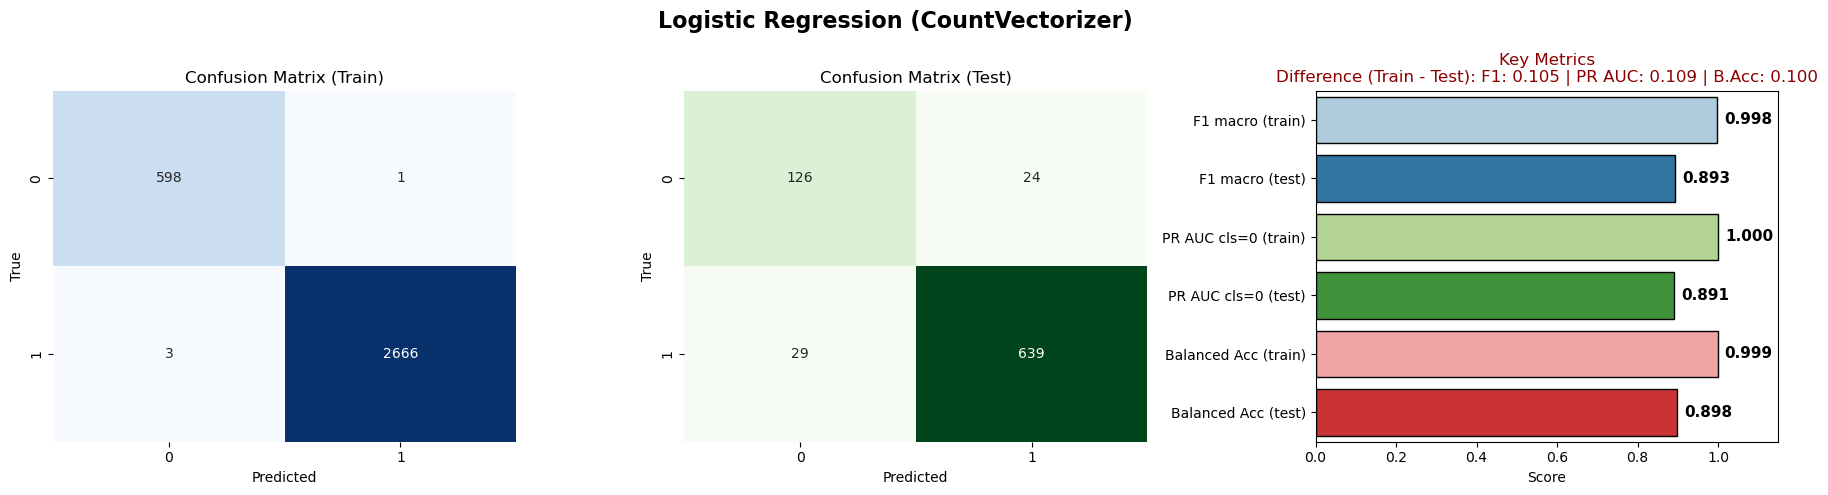

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.813,0.840,0.826,150.000
1,0.964,0.957,0.960,668.000
accuracy,0.935,0.935,0.935,0.935
macro avg,0.888,0.898,0.893,818.000
weighted avg,0.936,0.935,0.936,818.000


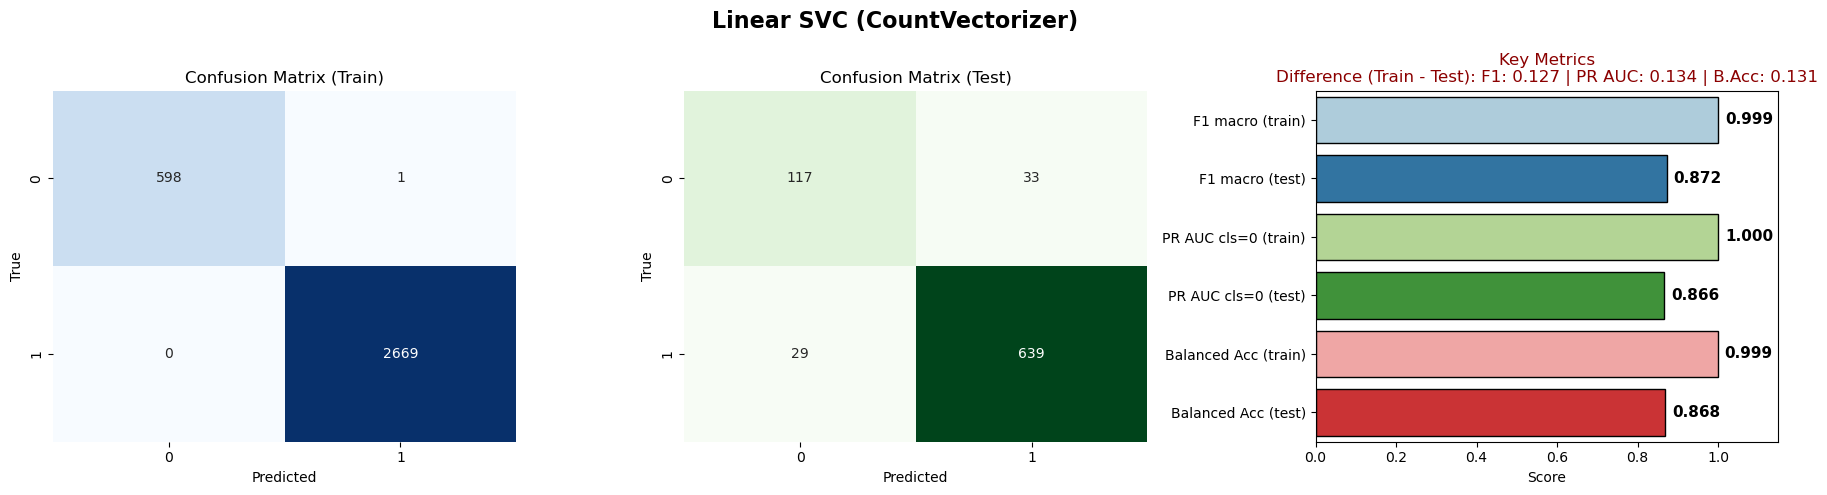

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.801,0.780,0.791,150.000
1,0.951,0.957,0.954,668.000
accuracy,0.924,0.924,0.924,0.924
macro avg,0.876,0.868,0.872,818.000
weighted avg,0.923,0.924,0.924,818.000


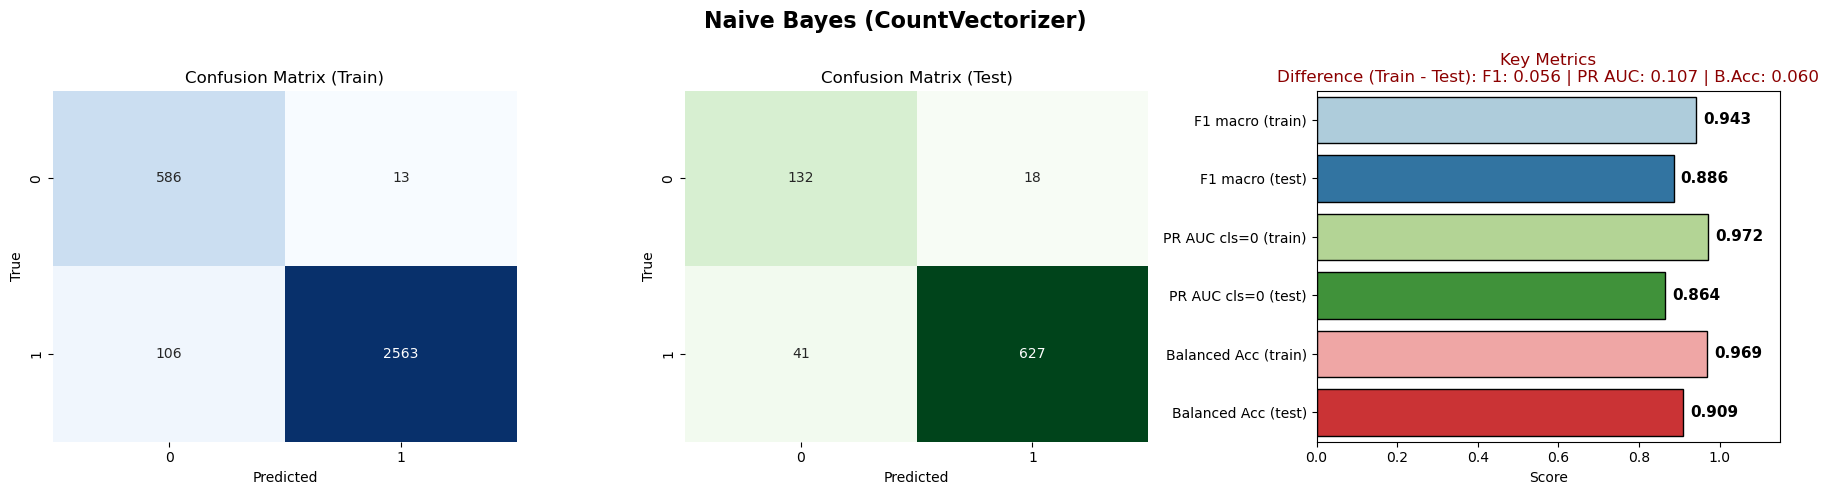

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.763,0.880,0.817,150.000
1,0.972,0.939,0.955,668.000
accuracy,0.928,0.928,0.928,0.928
macro avg,0.868,0.909,0.886,818.000
weighted avg,0.934,0.928,0.930,818.000


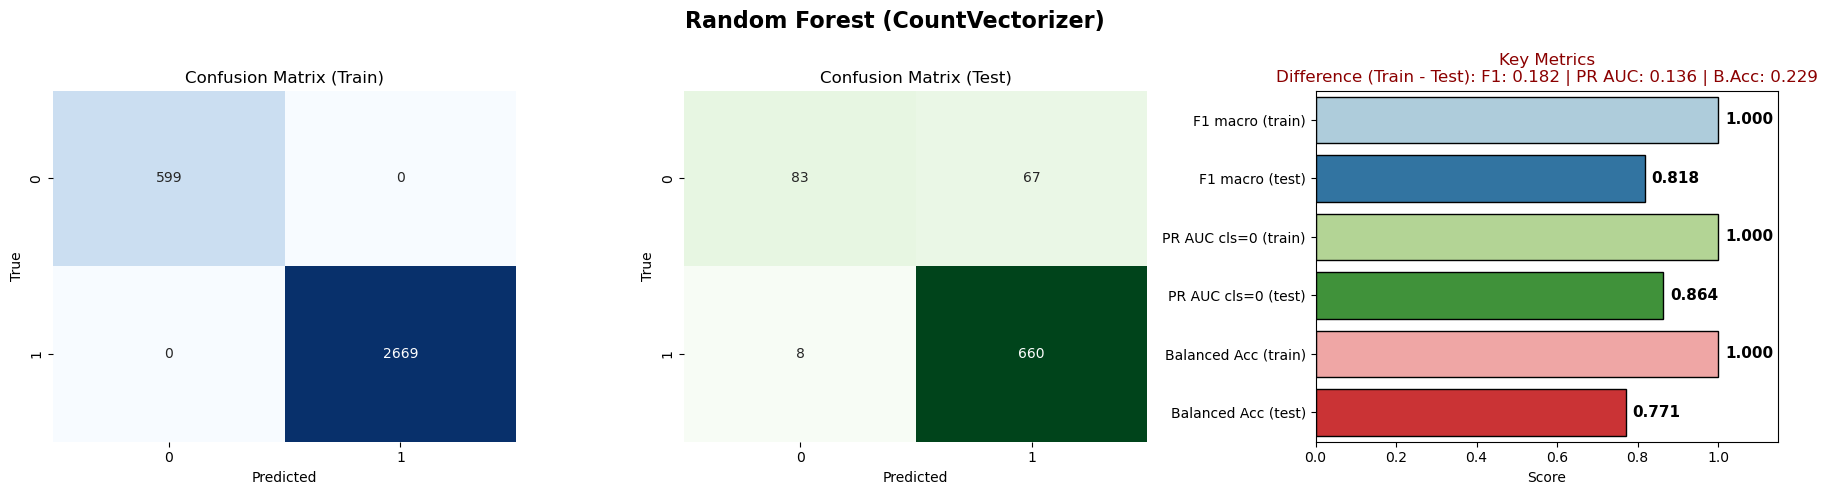

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.912,0.553,0.689,150.000
1,0.908,0.988,0.946,668.000
accuracy,0.908,0.908,0.908,0.908
macro avg,0.910,0.771,0.818,818.000
weighted avg,0.909,0.908,0.899,818.000


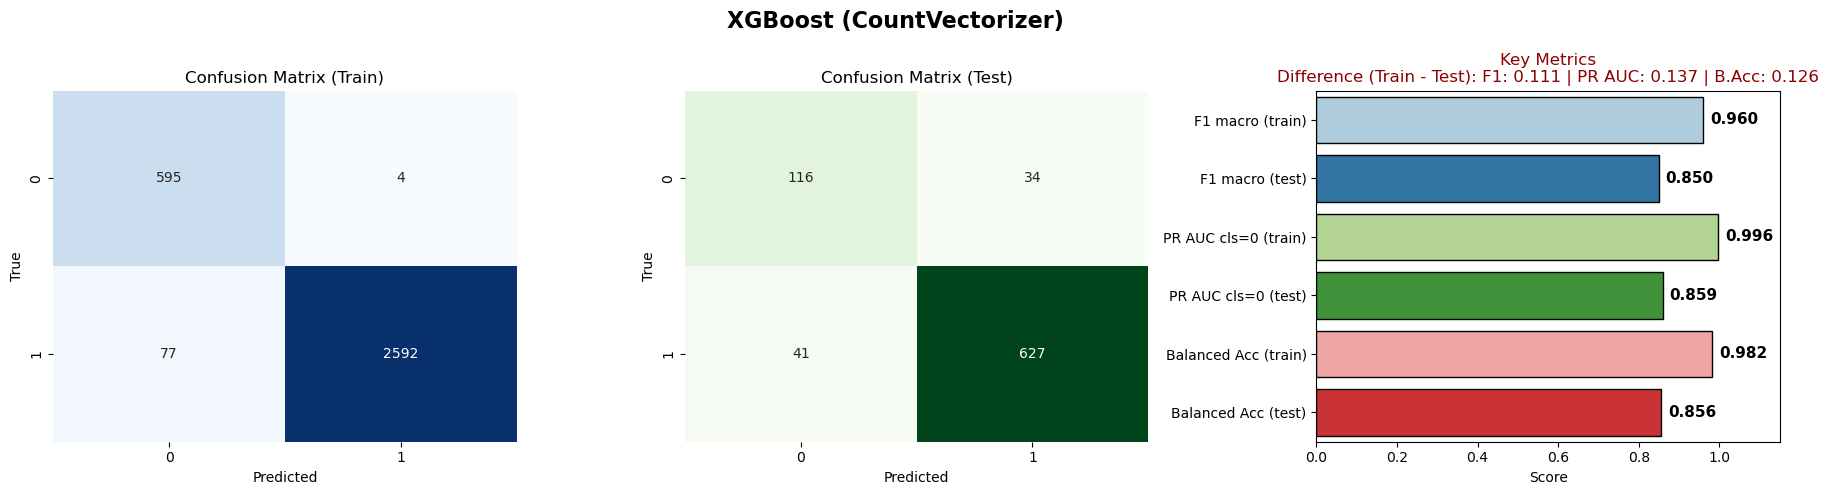

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.739,0.773,0.756,150.000
1,0.949,0.939,0.944,668.000
accuracy,0.908,0.908,0.908,0.908
macro avg,0.844,0.856,0.850,818.000
weighted avg,0.910,0.908,0.909,818.000


In [7]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0),
    "Linear SVC": LinearSVC(class_weight='balanced', max_iter=1000, random_state=0),
    "Naive Bayes": MultinomialNB(alpha=0.5, fit_prior=False),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=0, n_estimators=100, criterion='entropy'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='aucpr', scale_pos_weight=0.25)
}

for name, model in models.items():
    model.fit(X_train_countvectorizer, y_train)
    display_model_dashboard(name + ' (CountVectorizer)', model, X_train_countvectorizer, y_train, X_test_countvectorizer, y_test)

- Most algorithms show signs of **overfitting**.
- **Linear models** (Logistic Regression, Linear SVC):
    - Show decent performance (`F1-macro` on the test set is $0.87–0.89$), but the gap between train and test scores (Difference) is $0.105$ and $0.127$, respectively.
    - The models lose their generalization ability on unseen data.

- **Tree-based models** (Random Forest):
    - Showed the lowest performance.
    - Metrics on the training set are perfect ($1.000$), but `F1` drops to $0.818$ on the test set.
    - The model failed to recognize $Class-0$ (`Recall` is only $0.553$).

- **Bayes** (Naive Bayes):
 - Turned out to be the most stable model (the difference is only $0.056$),
- However, its overall predictive power is lower compared to Logistic Regression.

**Conclusion**: The models recognize $Class-1$ well but struggle significantly and make errors on the minority $Class-0$.

## TfidfVectorizer

In [8]:
X_train = text_cleaner_spacy(X_train)   # Apply custom text cleaning directly to the datasets.
X_test = text_cleaner_spacy(X_test)

# Vectorization
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),              # Consider both single words and word pairs (unigrams and bigrams)
    min_df=5,                        # Ignore words/phrases that appear in fewer than 5 texts
    sublinear_tf=True                # Apply sublinear TF scaling (1 + log(tf))
)
X_train = vectorizer.fit_transform(X_train)   
X_test = vectorizer.transform(X_test)

X_train.shape, X_test.shape

((3268, 6000), (818, 6000))

**text_cleaner_spacy** - a text preprocessing function that:

- Converts emojis to text (e.g., 😊 -> :smile:).
- Converts text to lowercase.
- Replaces repeated exclamation marks, question marks, and ellipses with special tokens (`<multi_excl>`, `<multi_quest>`, `<ellipsis>`).
- Normalizes duplicated letters (`coooool` -> `cool`).
- Passes the cleaned text to **spaCy** for lemmatization and filtering:
    - Retains negation particles like `not`, `no`, and `n't` (e.g., `not good`).
    - Removes stop words, punctuation, spaces, and numbers.
    - Replaces the remaining tokens with their lemmas (e.g., `running` -> `run`).

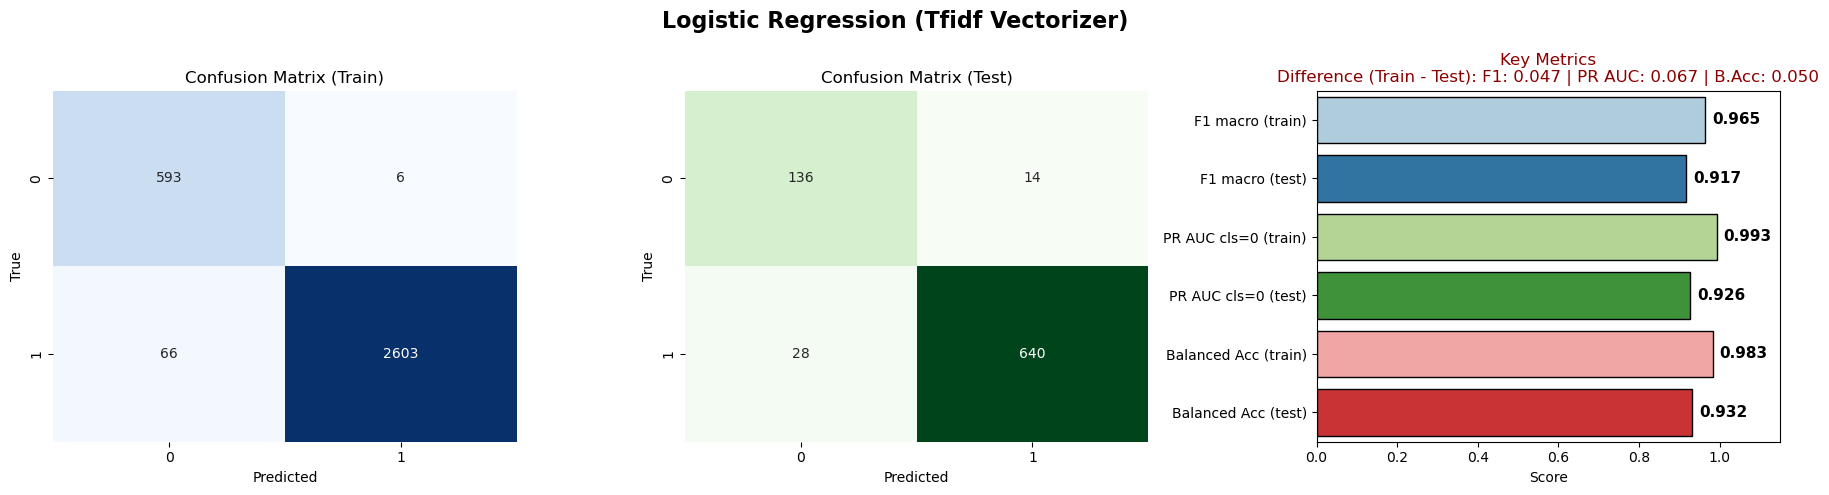

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.829,0.907,0.866,150.000
1,0.979,0.958,0.968,668.000
accuracy,0.949,0.949,0.949,0.949
macro avg,0.904,0.932,0.917,818.000
weighted avg,0.951,0.949,0.950,818.000


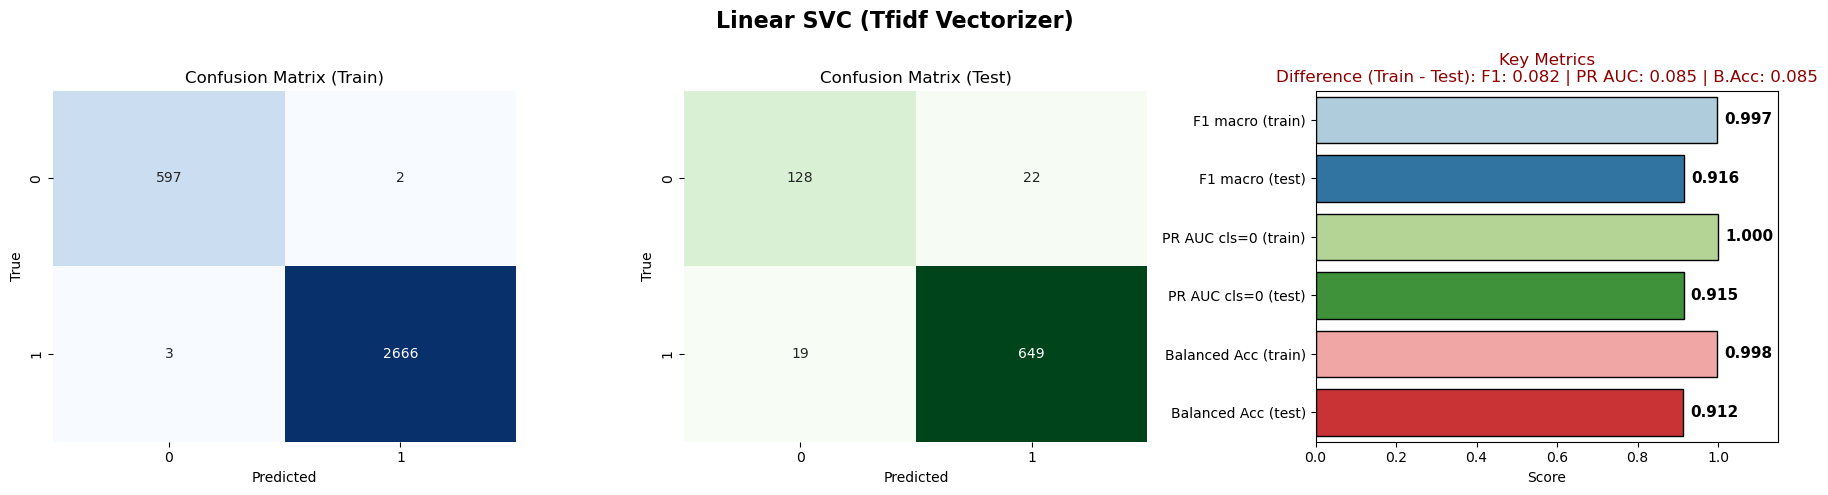

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.871,0.853,0.862,150.00
1,0.967,0.972,0.969,668.00
accuracy,0.950,0.950,0.950,0.95
macro avg,0.919,0.912,0.916,818.00
weighted avg,0.950,0.950,0.950,818.00


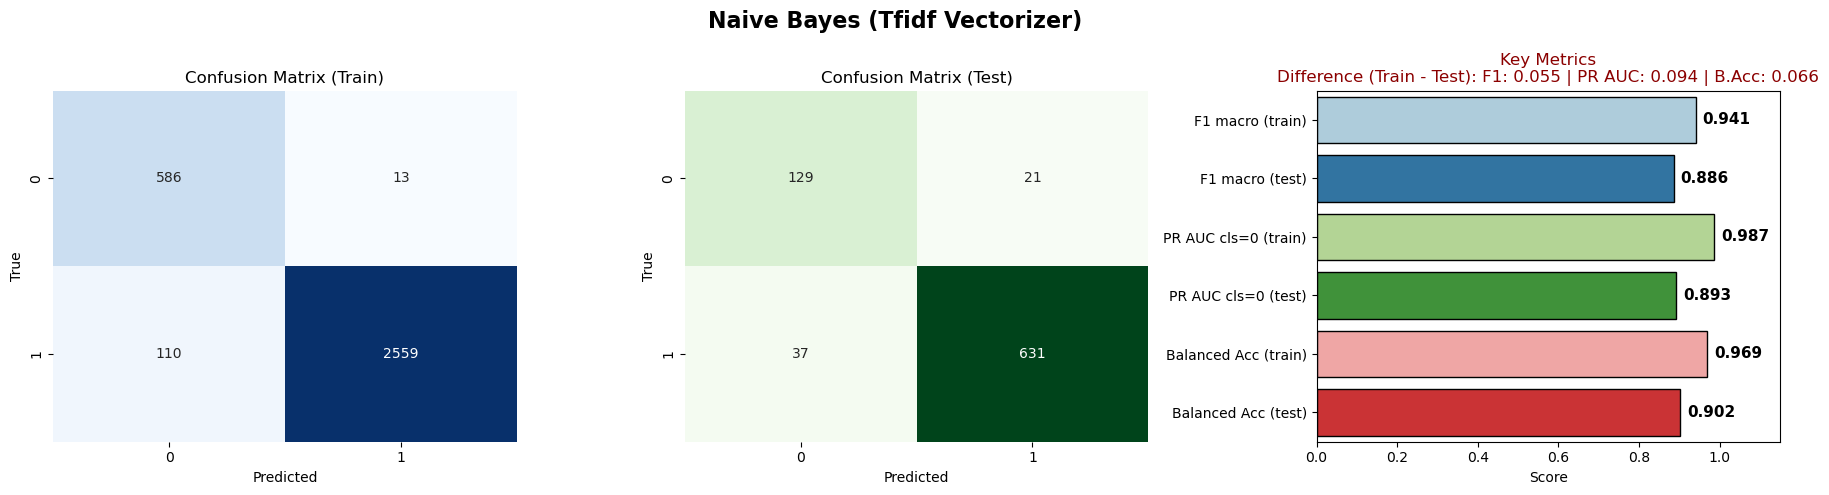

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.777,0.860,0.816,150.000
1,0.968,0.945,0.956,668.000
accuracy,0.929,0.929,0.929,0.929
macro avg,0.872,0.902,0.886,818.000
weighted avg,0.933,0.929,0.930,818.000


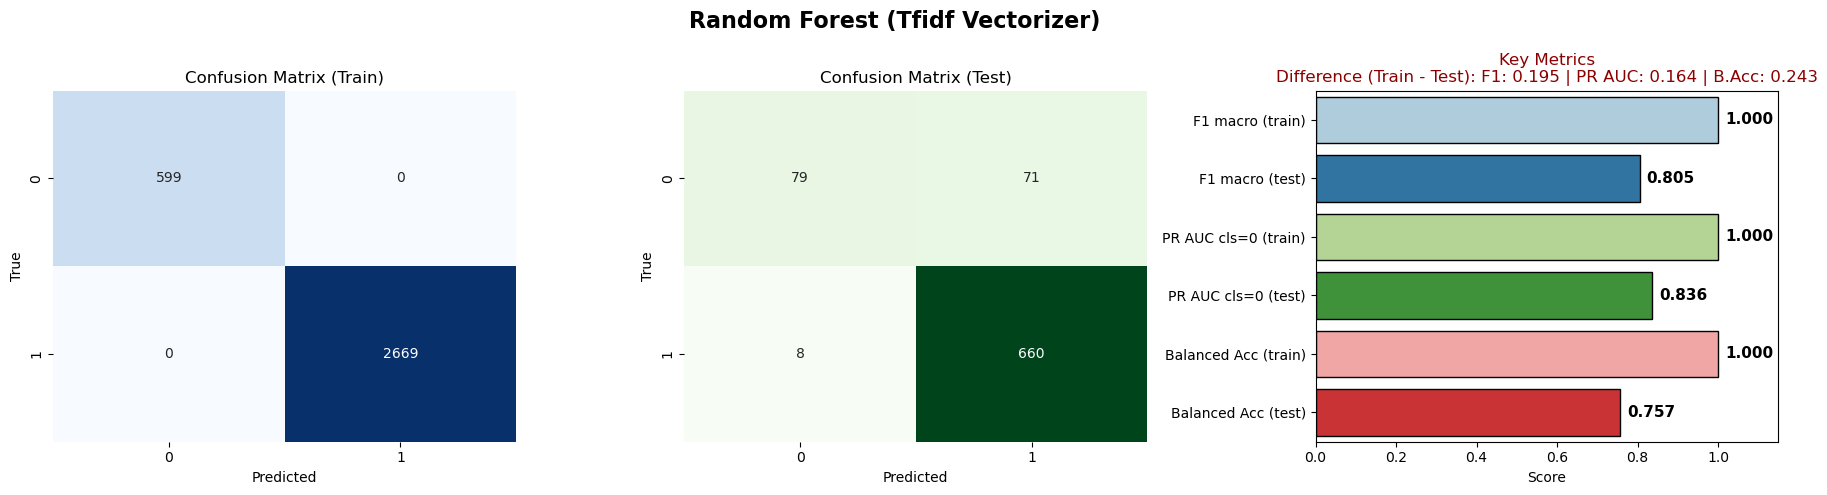

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.908,0.527,0.667,150.000
1,0.903,0.988,0.944,668.000
accuracy,0.903,0.903,0.903,0.903
macro avg,0.905,0.757,0.805,818.000
weighted avg,0.904,0.903,0.893,818.000


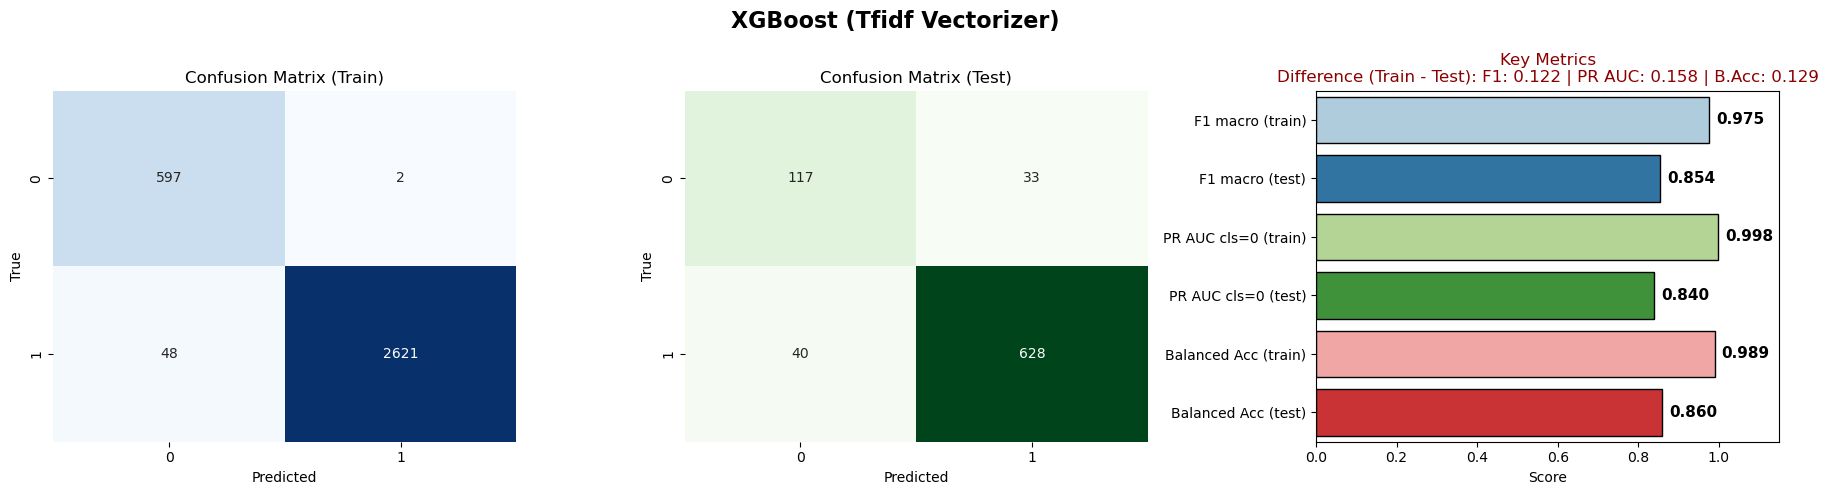

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.745,0.780,0.762,150.000
1,0.950,0.940,0.945,668.000
accuracy,0.911,0.911,0.911,0.911
macro avg,0.848,0.860,0.854,818.000
weighted avg,0.913,0.911,0.912,818.000


In [9]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0),
    "Linear SVC": LinearSVC(class_weight='balanced', max_iter=1000, random_state=0),
    "Naive Bayes": MultinomialNB(alpha=0.5, fit_prior=False),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=0, n_estimators=100, criterion='entropy'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='aucpr', scale_pos_weight=0.25)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    display_model_dashboard(name + ' (Tfidf Vectorizer)', model, X_train, y_train, X_test, y_test)

* SpaCy lemmatization, preservation of negations/emojis, and sublinear TF-IDF (`sublinear_tf=True`) improved overall performance, particularly for linear models.
* **Linear models** (Logistic Regression, Linear SVC):
* For Logistic Regression, the `F1-macro` score increased from $0.893$ to $0.912$, and the overfitting gap (Difference) was halved (from $0.105$ to $0.051$).
* The ability to detect the challenging Class $0$ (`Recall`) improved from $0.840$ to $0.900$!


* **Random Forest**:
* This approach did not benefit tree-based models.
* Overfitting worsened (the train-test gap increased from $0.182$ previously to $0.211$ now).
* `Recall` for Class $0$ dropped significantly ($0.493$).



**Conclusion**: The second approach is more optimal. The combination of SpaCy + TF-IDF + Logistic Regression or Linear SVC resulted in the most stable and accurate model at this stage.

In [10]:
# List of all additional features (metadata, text statistics, sentiment scores)
features = ['cool', 'useful', 'funny', 'length', 'year', 'month', 'dayofweek', 'day', 'is_weekend', 'user_count', 'business_count',
            'word_count', 'num_sentences', 'digit_count', 'num_questions', 'num_exclam', 'score_vader','score_afinn_norm', 'score_bing_norm', 
            'nrc_pos_norm', 'nrc_neg_norm', 'polarity', 'subjectivity', 'vader_deviation']

# Keep only these selected numerical columns in the X matrix (excluding the raw text itself)
X_features = df[features]

X_train_features, X_test_features, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=0, stratify=y)

X_train_features.shape, X_test_features.shape

((3268, 24), (818, 24))

## Yeo-Johnson transformation 

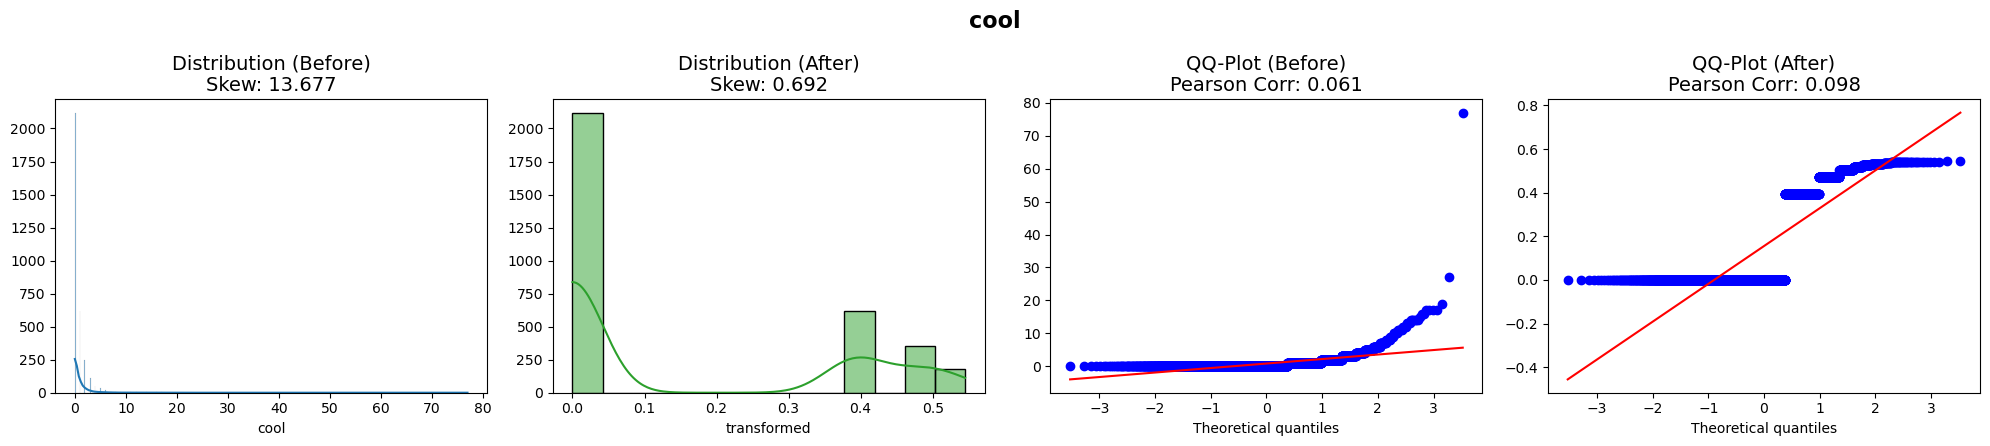

--------------------------------------------------------------------------------------------------------------------------------------------------------


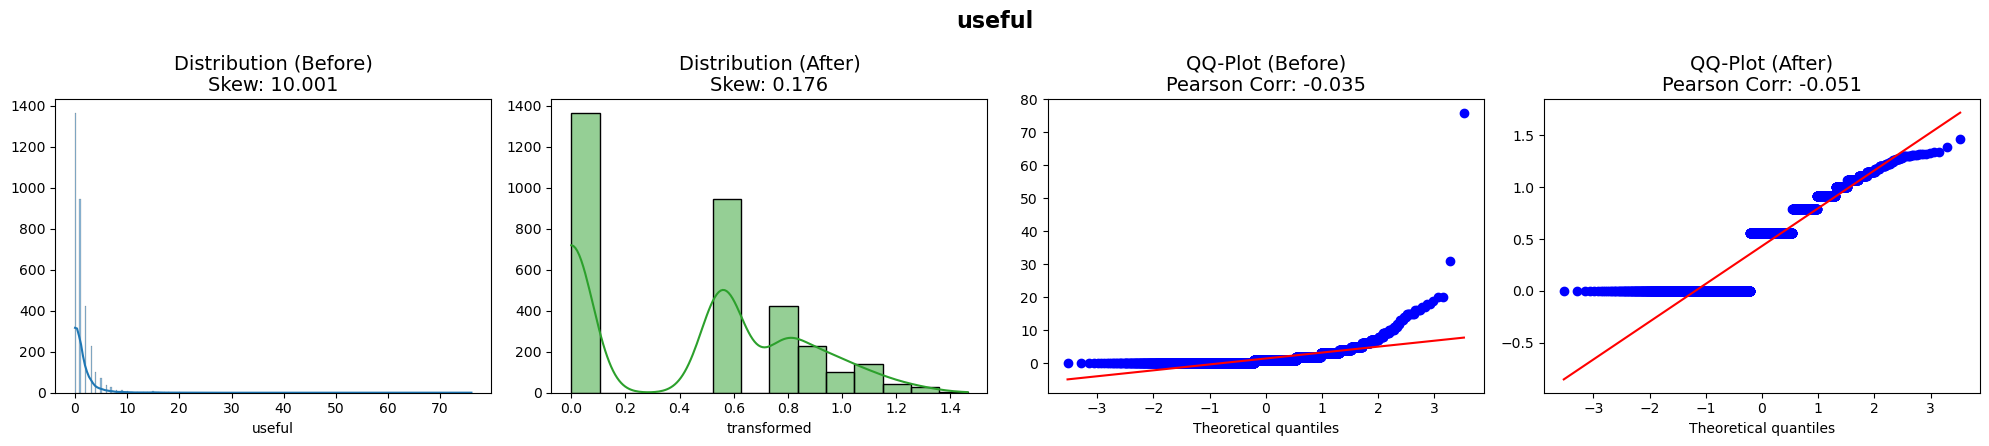

--------------------------------------------------------------------------------------------------------------------------------------------------------


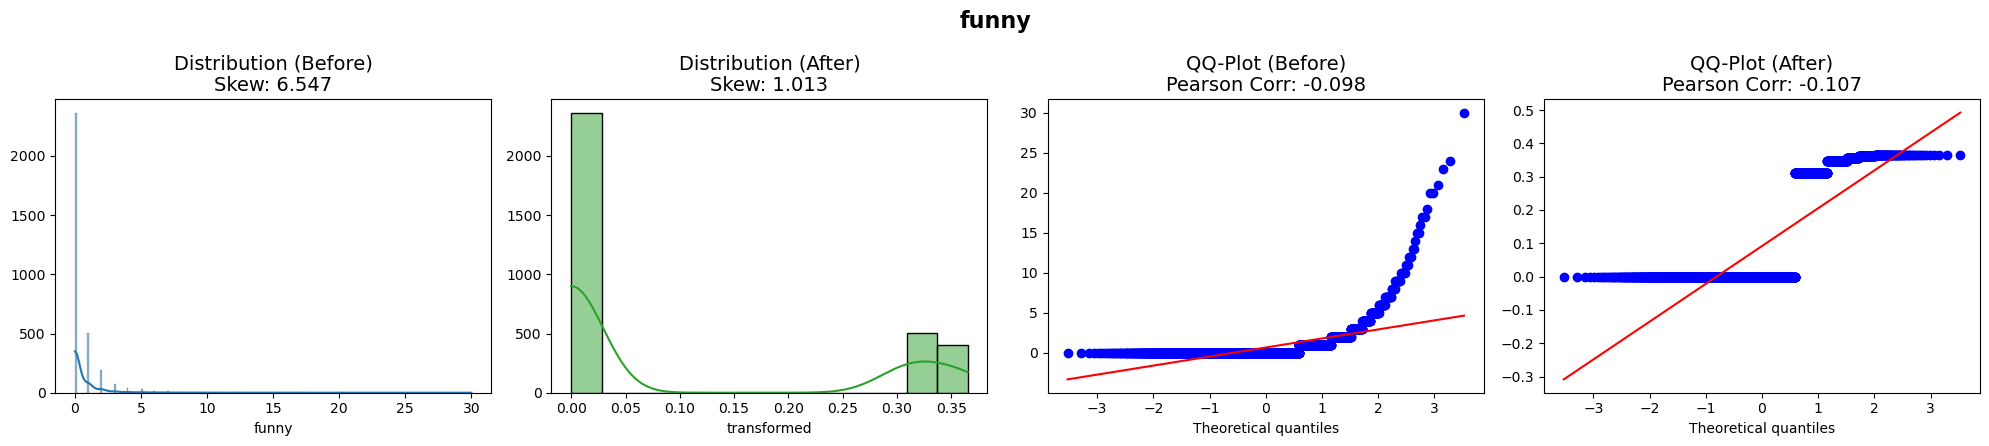

--------------------------------------------------------------------------------------------------------------------------------------------------------


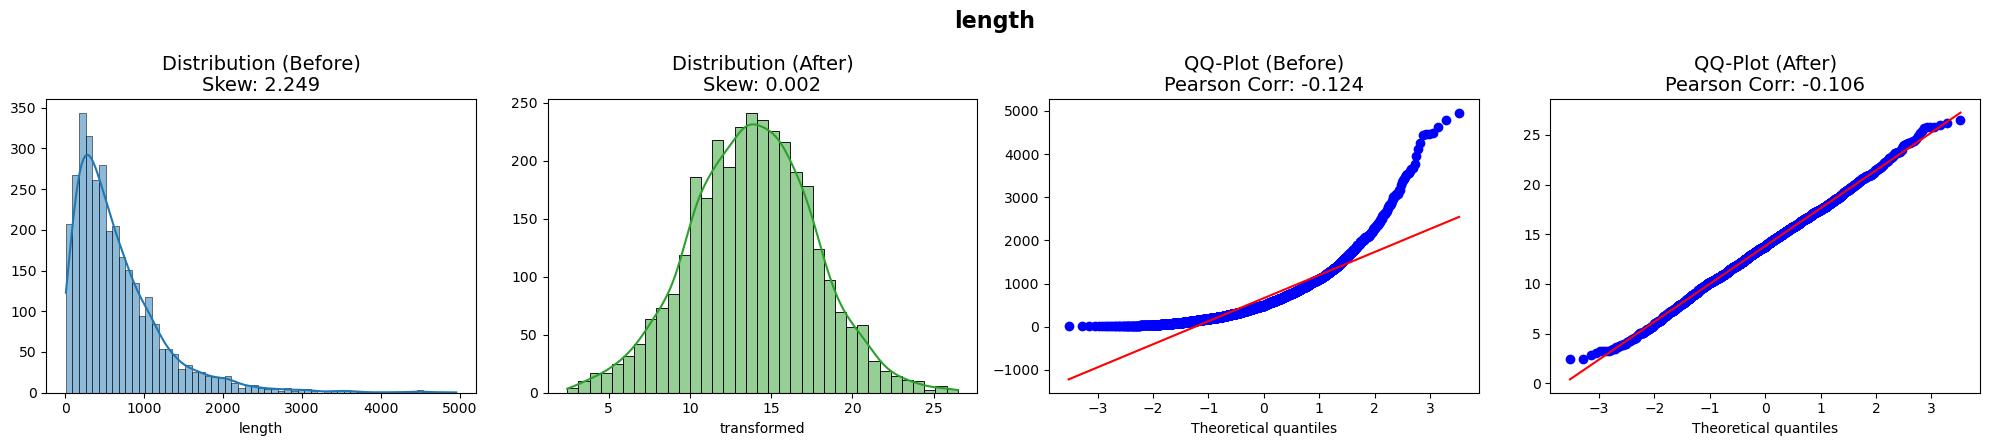

--------------------------------------------------------------------------------------------------------------------------------------------------------


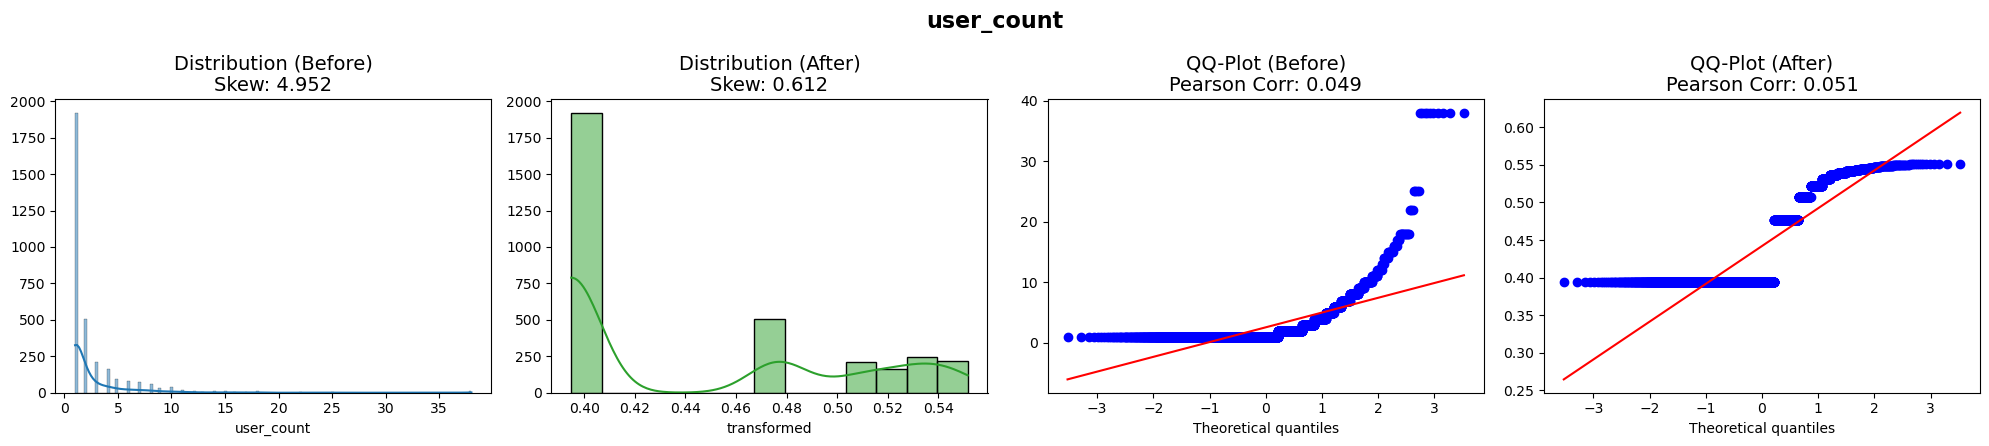

--------------------------------------------------------------------------------------------------------------------------------------------------------


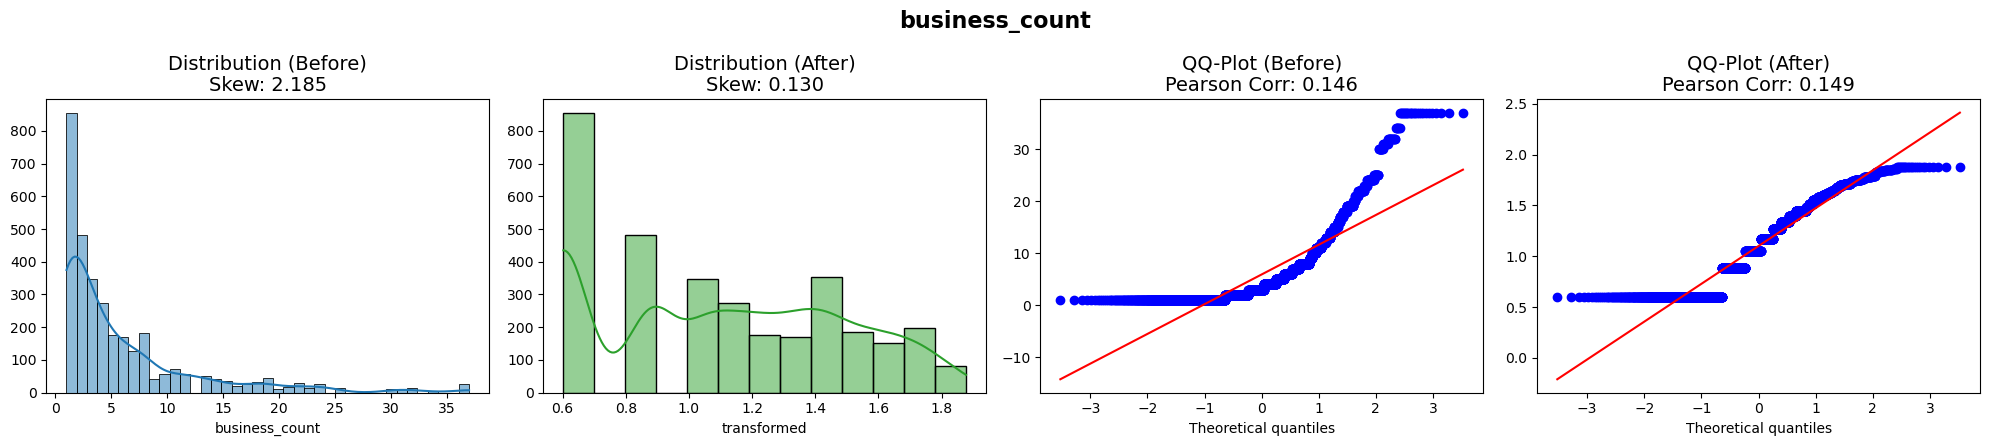

--------------------------------------------------------------------------------------------------------------------------------------------------------


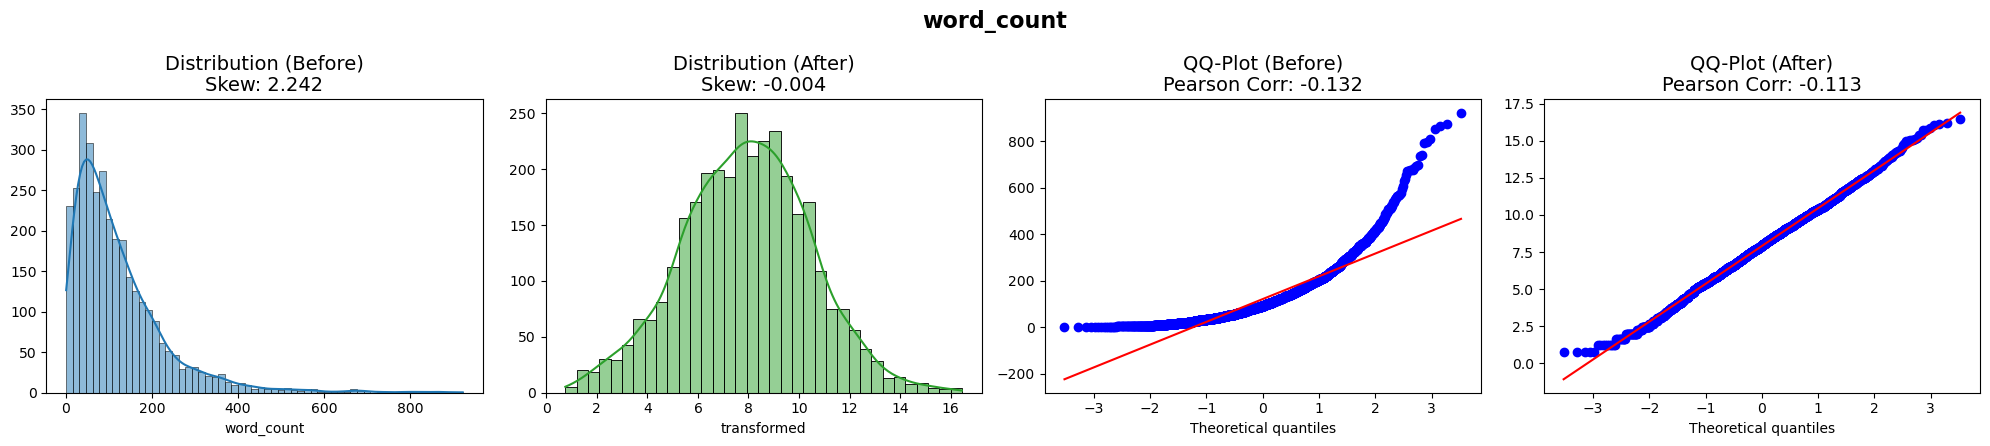

--------------------------------------------------------------------------------------------------------------------------------------------------------


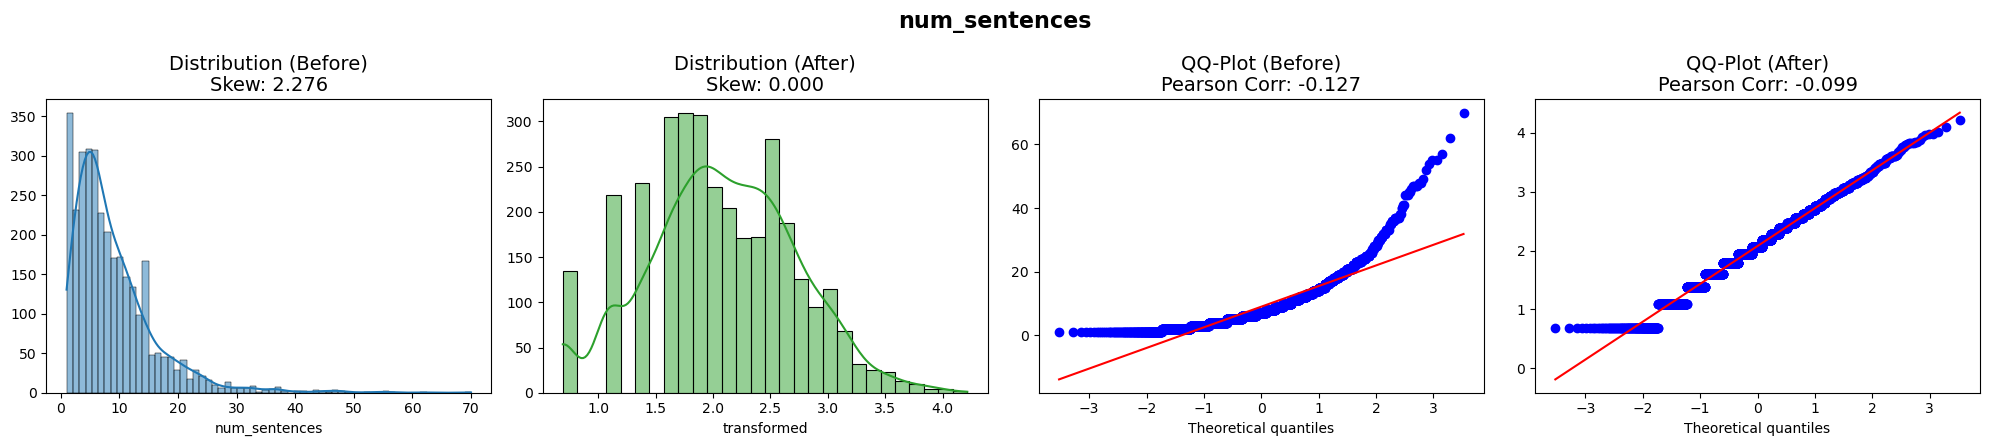

--------------------------------------------------------------------------------------------------------------------------------------------------------


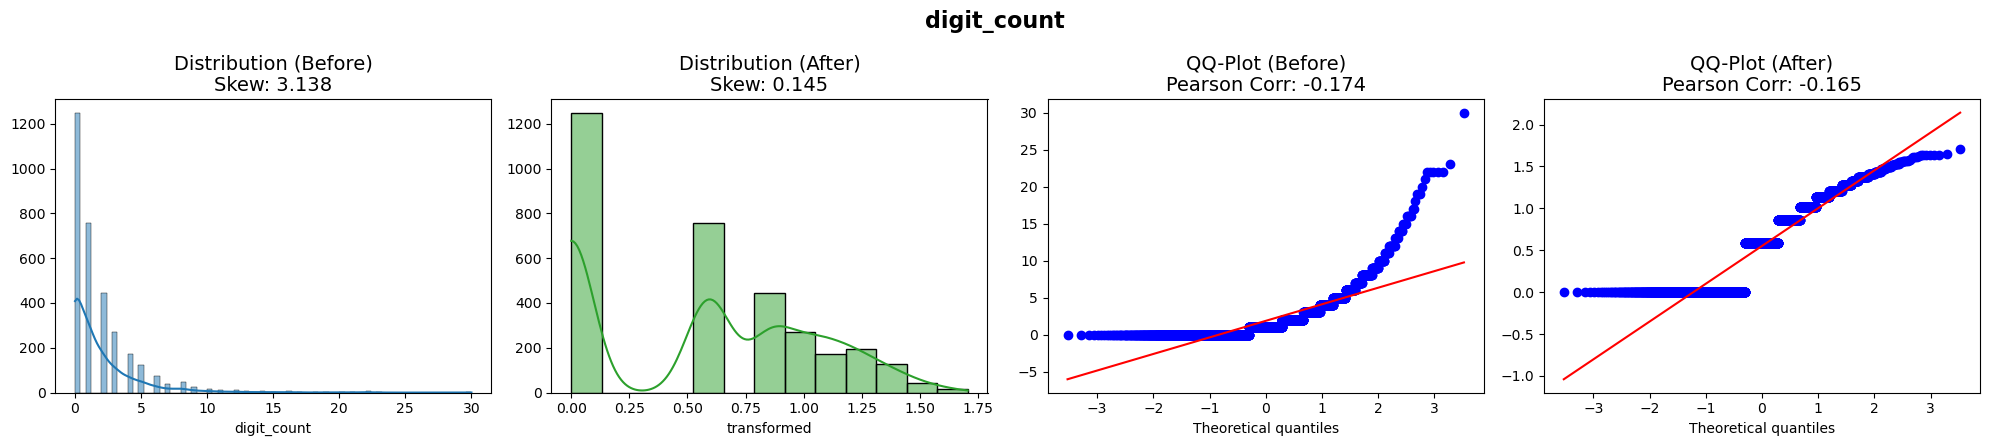

--------------------------------------------------------------------------------------------------------------------------------------------------------


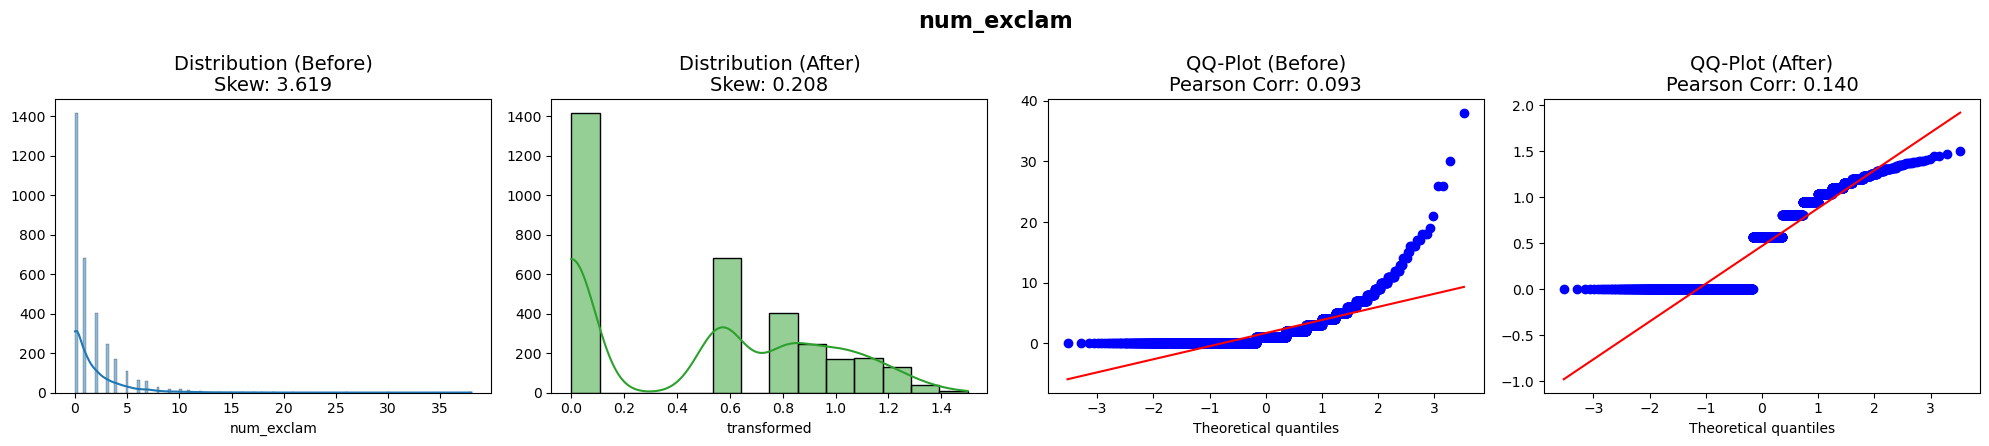

--------------------------------------------------------------------------------------------------------------------------------------------------------


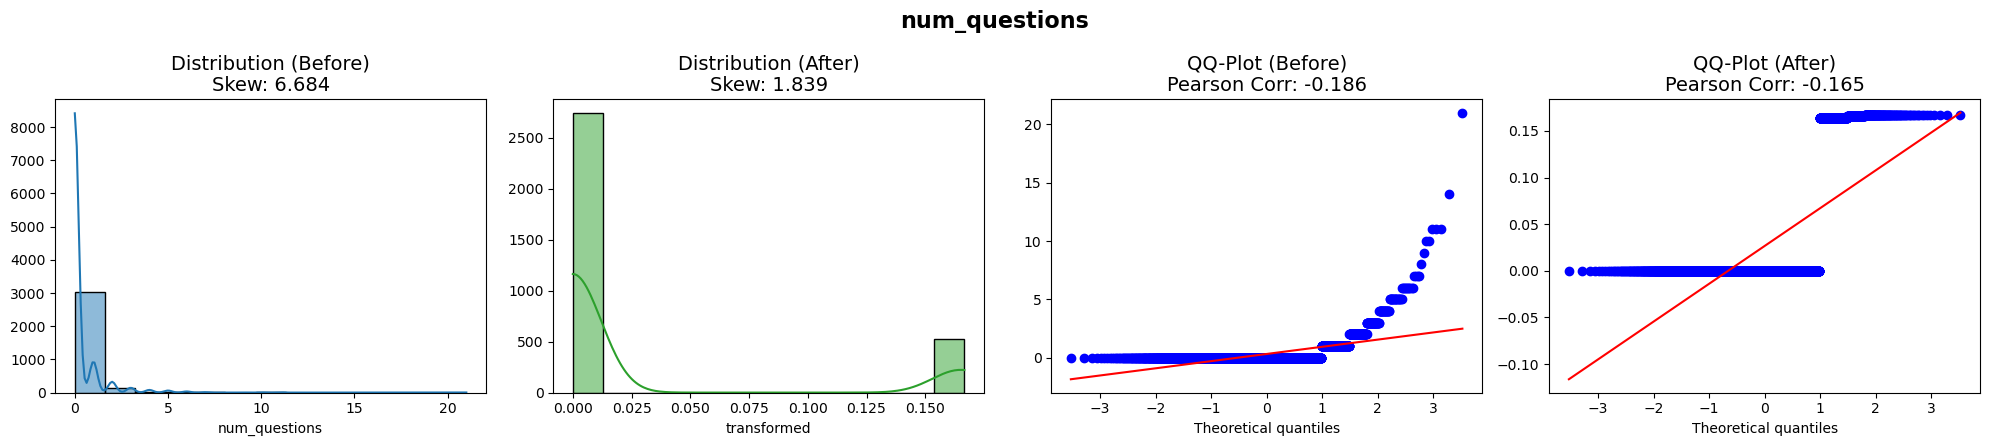

--------------------------------------------------------------------------------------------------------------------------------------------------------


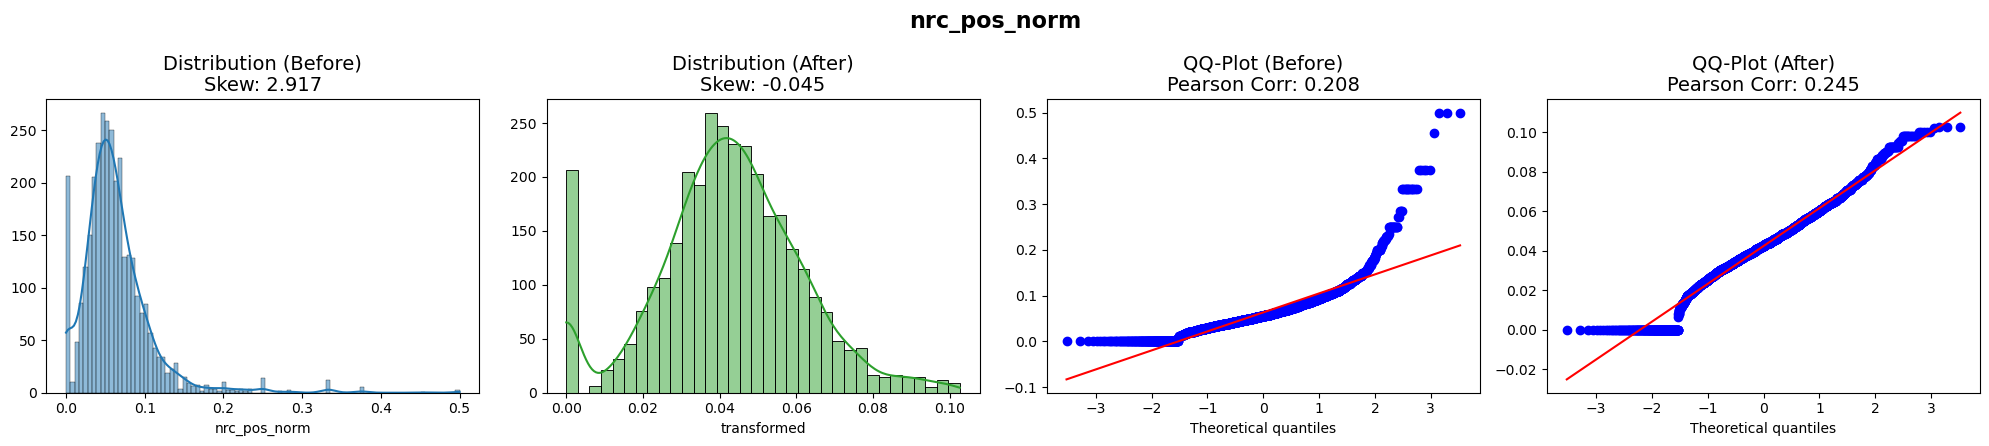

--------------------------------------------------------------------------------------------------------------------------------------------------------


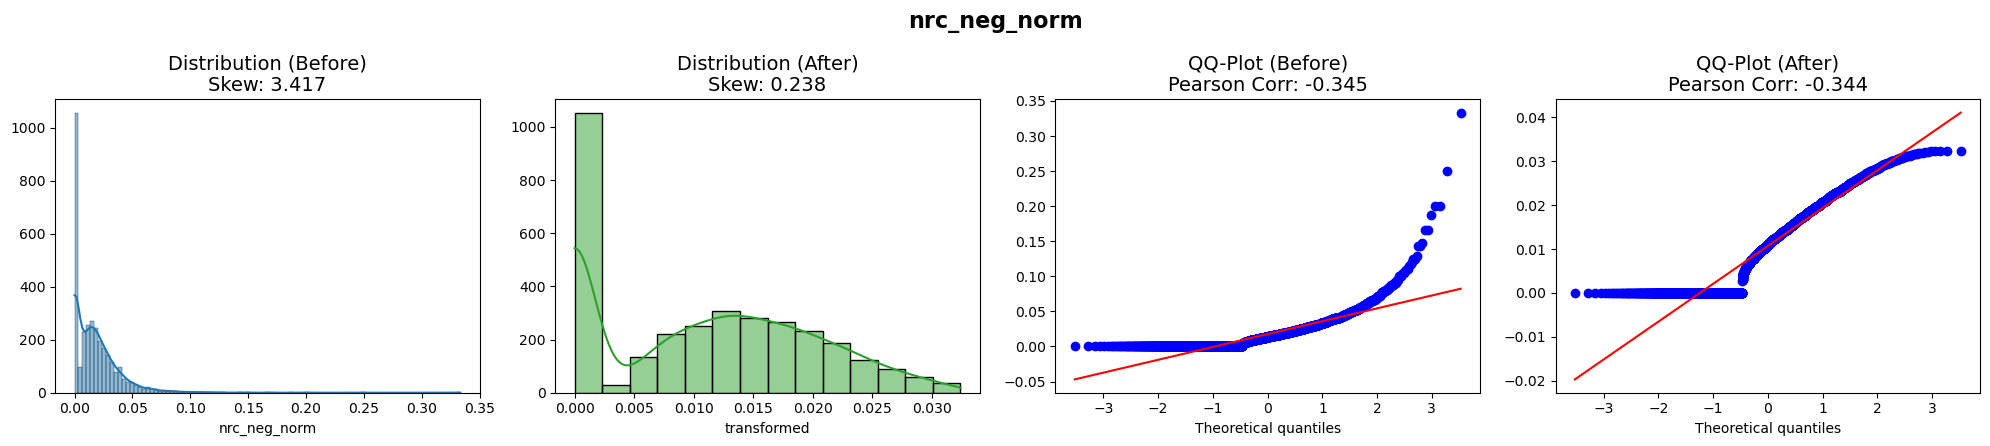

--------------------------------------------------------------------------------------------------------------------------------------------------------


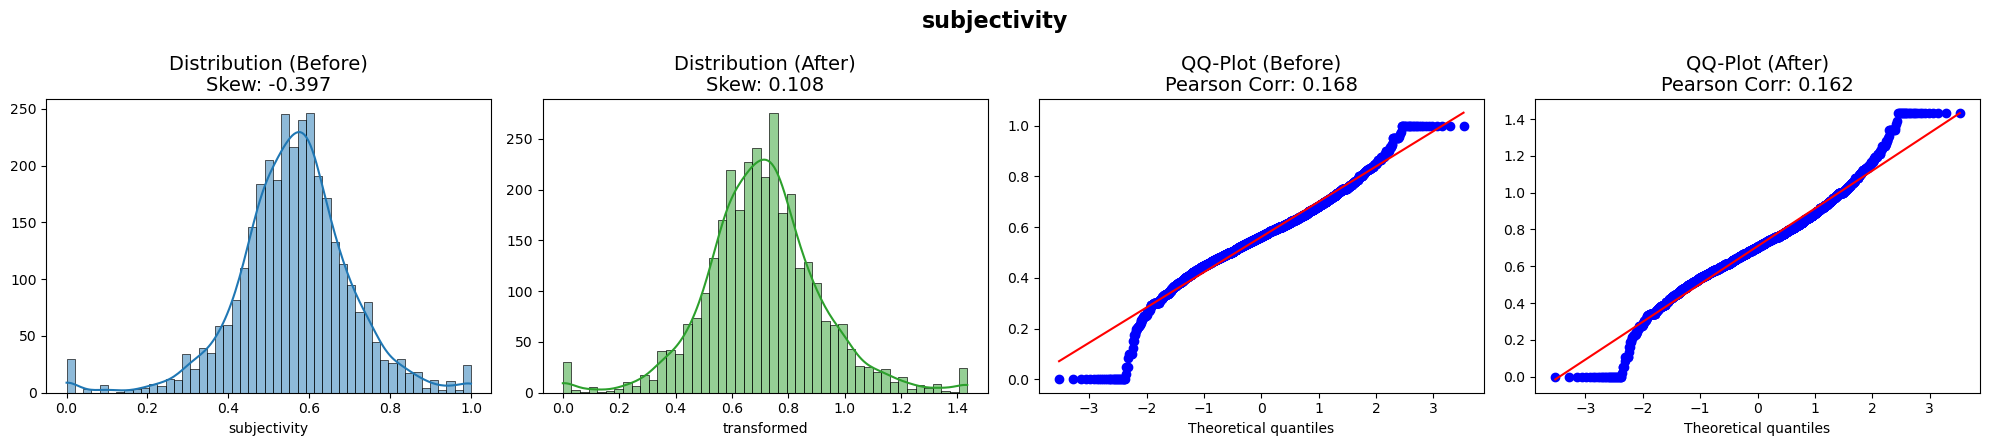

--------------------------------------------------------------------------------------------------------------------------------------------------------


In [11]:
# List of features with skewed distributions
features_yj = ['cool', 'useful', 'funny', 'length', 'user_count', 'business_count', 'word_count',
       'num_sentences', 'digit_count', 'num_exclam', 'num_questions', 'nrc_pos_norm', 'nrc_neg_norm', 'subjectivity']

# Loop through each feature, apply the Yeo-Johnson transformation using our custom function, and plot the "Before/After" results
for i in features_yj:
    yeojohnson_transform_analysis(X_train_features, y_train, feature_name=i)

**Continuous variables**:

* For text features (`length`, `word_count`, `num_sentences`) and sentiment scores (`nrc_pos_norm`), skewness decreased to almost zero after the transformation ($0.002$, $-0.004$).
* The distribution plot became shaped like a symmetrical "bell curve", and the blue dots on the Q-Q plot aligned almost perfectly along the red diagonal line.

**Discrete variables**:

* Reaction and activity counters (`cool`, `useful`, `funny`, `user_count`, `num_exclam`) contain a large number of zeros.
* It is mathematically impossible to transform them to resemble a bell curve.
* However, the transformation reduced the number of outliers. For example, the skewness of `cool` dropped from $13.6$ to $0.69$.

**Slight increase in correlation**

* For some features (e.g., `cool`, `useful`, `nrc_pos_norm`), the Pearson linear correlation with the target increased slightly after the transformation.

**Conclusion**: The Yeo-Johnson algorithm accomplished its task — making the data more "suitable" for linear models.

In [12]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# Loop through the list of features and apply the Yeo-Johnson transformation
for col in features_yj:
    X_train_features[col + '_yj'] = pt.fit_transform(X_train_features[[col]])
    X_test_features[col + '_yj'] = pt.transform(X_test_features[[col]])

## MinMax-, Standard-, Robust- Scaler

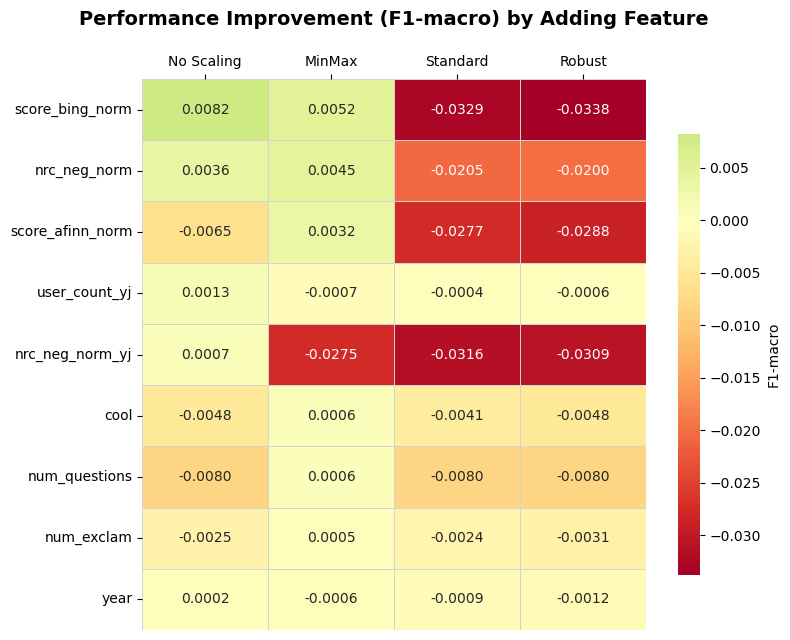

In [13]:
scalers = {
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler(),
    "Robust": RobustScaler()
}

scaled_dfs = {}

# Add the dataframe without scaling (baseline)
scaled_dfs["No Scaling"] = X_train_features.copy()

# Add the results from the scalers
for name, scaler in scalers.items():
    scaled_dfs[name] = scaler.set_output(transform="pandas").fit_transform(X_train_features)

# Calculate the baseline score
score_base = evaluate_model(X_train, y_train)


results = pd.DataFrame(index=X_train_features.columns)

# Iterate over each scaling method
for scaler_name, X_scaled in scaled_dfs.items():
    score_diffs = []
    for col in X_scaled.columns:
        X_combined = hstack([X_train, X_scaled[[col]].values])  # Horizontally stack one scaled feature to the text matrix
        score = evaluate_model(X_combined, y_train)             # Get the cross-validation score for this new combination
        score_diff = score - score_base                         # Calculate the metric improvement (or drop) relative to the baseline score
        score_diffs.append(score_diff)
    results[scaler_name] = score_diffs                          # Save the list of score differences as a new column in the results table
    
# Keep only the features that showed an improvement (> 0) with at least one scaler
improved_features = results[(results > 0).any(axis=1)].copy()

# Sort from highest to lowest improvement
improved_features['max_diff'] = improved_features.max(axis=1)
improved_features = improved_features.sort_values('max_diff', ascending=False).drop(columns='max_diff')


# Visualization
# Dynamic plot height (0.5 inches per feature)
fig_height = len(improved_features) * 0.5 + 2

plt.figure(figsize=(8, fig_height))

ax = sns.heatmap(
    improved_features, 
    annot=True, 
    cmap="RdYlGn",     
    center=0,        
    fmt=".4f", 
    linewidths=0.5,    
    linecolor='lightgray',
    cbar_kws={"shrink": 0.8, "label": "F1-macro"} # Colorbar legend settings
)

# Move X-axis column names to the top 
ax.xaxis.tick_top()

plt.title("Performance Improvement (F1-macro) by Adding Feature\n", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

* `MinMaxScaler` provides a performance improvement.
* `StandardScaler` and `RobustScaler` perform worse than the baseline.

## Feature selection

### Smart Correlated Selection

In [14]:
scaler = MinMaxScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X_train_features)

judge_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)

selector = SmartCorrelatedSelection(
    method='pearson', 
    threshold=0.8, 
    selection_method='model_performance',
    estimator=judge_model,  
    scoring='f1_macro', 
    cv=3  
)

# Drop correlated features (eliminate multicollinearity)
X_corr_selected = selector.fit_transform(X_scaled, y_train)

print(f"Dropped features:\n{'-'*30}\n{selector.features_to_drop_}\n")
print(f"\nSCS kept {len(X_corr_selected.columns)} features out of {len(X_scaled.columns)}:\n{'-'*30}\n{X_corr_selected.columns.tolist()}")

Dropped features:
------------------------------
['business_count', 'cool', 'dayofweek', 'digit_count_yj', 'length', 'length_yj', 'num_sentences_yj', 'word_count', 'word_count_yj', 'nrc_neg_norm_yj', 'nrc_pos_norm', 'score_afinn_norm', 'subjectivity_yj']


SCS kept 25 features out of 38:
------------------------------
['useful', 'funny', 'year', 'month', 'day', 'is_weekend', 'user_count', 'num_sentences', 'digit_count', 'num_questions', 'num_exclam', 'score_vader', 'score_bing_norm', 'nrc_neg_norm', 'polarity', 'subjectivity', 'vader_deviation', 'cool_yj', 'useful_yj', 'funny_yj', 'user_count_yj', 'business_count_yj', 'num_exclam_yj', 'num_questions_yj', 'nrc_pos_norm_yj']


### Sequential Feature Selection

In [15]:
sfs = SFS(
    estimator=judge_model,
    k_features='best', 
    forward=False,      
    floating=True,
    scoring='f1_macro',
    cv=5,              
    n_jobs=-1   
)

# Floating Backward Selection: finding the feature combination that maximizes the F1-macro score
sfs.fit(X_corr_selected, y_train)

selected_features = list(sfs.k_feature_names_)
print(f"SFS kept {len(selected_features)} features out of {X_corr_selected.shape[1]}:\n{'-'*30}\n{list(selected_features)}")

SFS kept 15 features out of 25:
------------------------------
['month', 'day', 'digit_count', 'num_questions', 'score_vader', 'score_bing_norm', 'nrc_neg_norm', 'polarity', 'vader_deviation', 'cool_yj', 'funny_yj', 'user_count_yj', 'business_count_yj', 'num_exclam_yj', 'nrc_pos_norm_yj']


In [16]:
# Remove '_yj' from all list items
sfs_features = [name.replace('_yj', '') for name in selected_features] + ["text", "stars"]

In [17]:
df[sfs_features].to_parquet('../data/yelp_data_sfs_15.parquet')